# Assignment 5

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft2, fftshift, ifftshift
import skimage
from scipy.ndimage import fourier

### A) K-means Clustering

#### a) Read the exemplary color input image inputEx5_1.jpg and set up a three-dimensional RGB feature space (reshape)

In [2]:
 
# Load image
I = plt.imread(os.path.join("picturesA5","inputEx5_1.jpg"))
 
# Ensure image is RGB (drop alpha channel if present)
if I.ndim == 2:
    I = np.stack([I, I, I], axis=2)
elif I.shape[2] == 4:
    I = I[:, :, :3]
 
# Convert to double precision and normalize
I = I.astype(np.float64)
I = (I - I.min()) / (I.max() - I.min())
 
print(f"Image shape : {I.shape}")
print(f"Value range : [{I.min():.3f}, {I.max():.3f}]")
 
# Reshape to 3D RGB feature space: (H*W, 3)
H, W, C = I.shape
X = I.reshape(-1, C)



Image shape : (200, 200, 3)
Value range : [0.000, 1.000]


### Visualize Input Image

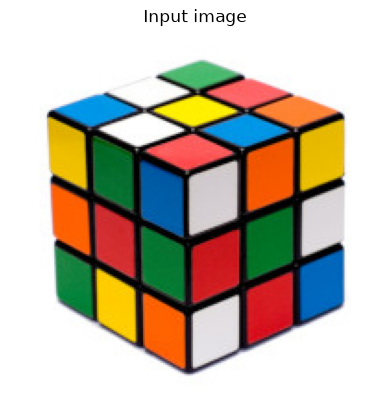

In [3]:
plt.imshow(I)
plt.title("Input image")
plt.axis("off")
plt.show()

#### b) Implement your own k-means clustering approach with random initialization (see lecture notes) to group the color features 

In [4]:
def kmeans(X, K, max_iter=100, tol=1e-4, seed=42):
    rng = np.random.default_rng(seed)
    N, D = X.shape
 
    # Random initialisation: pick K distinct pixels as starting centres
    idx = rng.choice(N, size=K, replace=False)
    centres = X[idx].copy()   # (K, D)
 
    labels = np.empty(N, dtype=int)
 
    for iteration in range(max_iter):
        # Squared Euclidean distance from every point to every centre
        X_sq     = (X ** 2).sum(axis=1, keepdims=True)          # (N, 1)
        C_sq     = (centres ** 2).sum(axis=1, keepdims=True).T  # (1, K)
        cross    = X @ centres.T                                 # (N, K)
        dists_sq = X_sq - 2 * cross + C_sq                      # (N, K)
 
        new_labels = dists_sq.argmin(axis=1)                     # (N,)
 
        # Update step
        new_centres = np.array([
            X[new_labels == k].mean(axis=0) if (new_labels == k).any()
            else centres[k]          # keep old centre if cluster is empty
            for k in range(K)
        ])
 
        # Convergence check
        centre_shift = np.linalg.norm(new_centres - centres)
        centres = new_centres
        labels  = new_labels
 
        print(f"  iter {iteration + 1:3d}  |  centre shift: {centre_shift:.6f}")
 
        if centre_shift < tol:
            print(f"  Converged after {iteration + 1} iterations.")
            break
 
    inertia = sum(
        ((X[labels == k] - centres[k]) ** 2).sum()
        for k in range(K)
        if (labels == k).any()
    )
 
    return centres, labels, inertia

In [6]:
K = 6 # number of colour clusters
 
centres, labels, inertia = kmeans(X, K=K)
 
print(f"\nCluster centres (RGB):")
for k, c in enumerate(centres):
    print(f"  Cluster {k}: R={c[0]:.3f}  G={c[1]:.3f}  B={c[2]:.3f}")


  iter   1  |  centre shift: 0.630990
  iter   2  |  centre shift: 0.334276
  iter   3  |  centre shift: 0.218946
  iter   4  |  centre shift: 0.089850
  iter   5  |  centre shift: 0.042726
  iter   6  |  centre shift: 0.032799
  iter   7  |  centre shift: 0.013676
  iter   8  |  centre shift: 0.004693
  iter   9  |  centre shift: 0.001905
  iter  10  |  centre shift: 0.000473
  iter  11  |  centre shift: 0.000463
  iter  12  |  centre shift: 0.000190
  iter  13  |  centre shift: 0.000217
  iter  14  |  centre shift: 0.000151
  iter  15  |  centre shift: 0.000000
  Converged after 15 iterations.

Cluster centres (RGB):
  Cluster 0: R=0.024  G=0.455  B=0.756
  Cluster 1: R=0.114  G=0.445  B=0.239
  Cluster 2: R=0.906  G=0.428  B=0.103
  Cluster 3: R=0.829  G=0.813  B=0.824
  Cluster 4: R=0.087  G=0.058  B=0.059
  Cluster 5: R=0.998  G=0.998  B=0.998


#### c) Select an appropriate number of clusters k, apply the algorithm and visualize the detected groups in feature and image space (e.g. with color coding).

  iter   1  |  centre shift: 0.630990
  iter   2  |  centre shift: 0.334276
  iter   3  |  centre shift: 0.218946
  iter   4  |  centre shift: 0.089850
  iter   5  |  centre shift: 0.042726
  iter   6  |  centre shift: 0.032799
  iter   7  |  centre shift: 0.013676
  iter   8  |  centre shift: 0.004693
  iter   9  |  centre shift: 0.001905
  iter  10  |  centre shift: 0.000473
  iter  11  |  centre shift: 0.000463
  iter  12  |  centre shift: 0.000190
  iter  13  |  centre shift: 0.000217
  iter  14  |  centre shift: 0.000151
  iter  15  |  centre shift: 0.000000
  Converged after 15 iterations.


NameError: name 'rng' is not defined

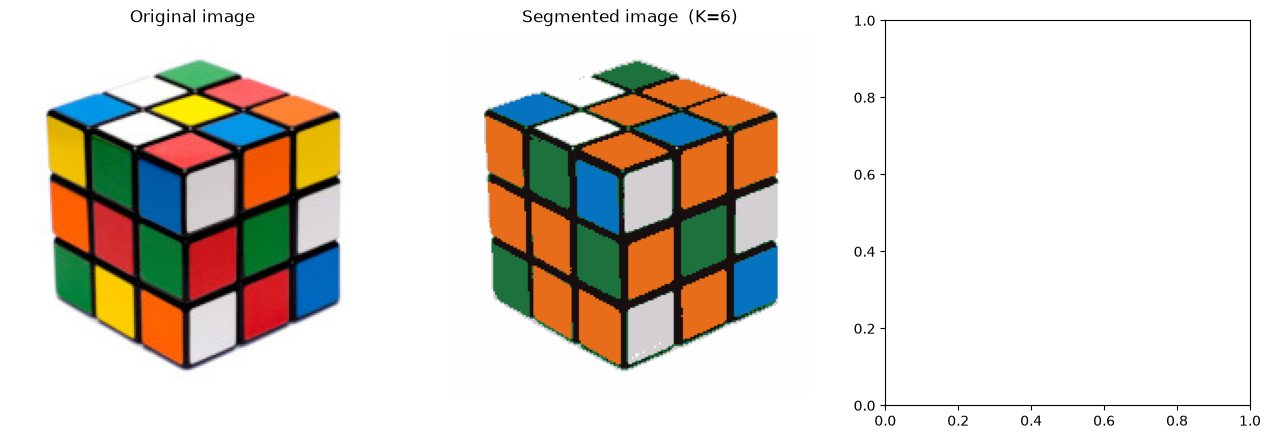

In [ ]:

rng    = np.random.default_rng(1)
sample = rng.choice(len(X), size=8_000, replace=False)

centres, labels, inertia = kmeans(X, K=K)

# Distinct colours for cluster annotation (one per cluster)
PALETTE = np.array([
    [0.92, 0.26, 0.20],   # red
    [0.18, 0.55, 0.84],   # blue
    [0.20, 0.73, 0.33],   # green
    [0.98, 0.76, 0.15],   # yellow
    [0.60, 0.29, 0.78],   # purple
    [0.97, 0.51, 0.09],   # orange
    [0.13, 0.74, 0.69],   # teal
    [0.85, 0.33, 0.64],   # pink
])[:K]
 
fig = plt.figure(figsize=(16, 5))
 
# Original image
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(I)
ax1.set_title("Original image")
ax1.axis("off")
 
# Segmented image (each pixel → its cluster centre colour)
segmented = centres[labels].reshape(H, W, C)
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(segmented)
ax2.set_title(f"Segmented image  (K={K})")
ax2.axis("off")
 
# RGB feature space (R–G projection) with cluster colouring
ax3 = fig.add_subplot(1, 3, 3)
 
sample = rng.choice(len(X), size=8_000, replace=False)
ax3.scatter(
    X[sample, 0], X[sample, 1],
    c=PALETTE[labels[sample]],
    s=2, alpha=0.4, linewidths=0
)
# Overlay cluster centres as large markers
for k in range(K):
    ax3.scatter(
        centres[k, 0], centres[k, 1],
        s=200, color=PALETTE[k],
        edgecolors="black", linewidths=1.2,
        zorder=5, label=f"Cluster {k}"
    )
ax3.set_xlabel("Red")
ax3.set_ylabel("Green")
ax3.set_title("RGB feature space\n(R-G projection, 8 000 px sample)")
ax3.legend(loc="upper left", markerscale=0.8, fontsize=8)
 
plt.tight_layout()
plt.show()


#### d) Extend the three-dimensional feature space with additional spatial support using the pixel positions (x, y) and test your algorithm on the five-dimensional feature space. Are the results different or significantly better?

In [ ]:
# Normalised pixel coordinates in [0, 1]
ys = np.linspace(0, 1, H)
xs = np.linspace(0, 1, W)
grid_x, grid_y = np.meshgrid(xs, ys)          # each (H, W)
 
coords = np.stack([grid_x, grid_y], axis=2)
X_xy   = coords.reshape(-1, 2)
 
X_5d = np.hstack([X, X_xy])
centres_5d, labels_5d, _ = kmeans(X_5d,  K=K) # K is set in b)

  iter   1  |  centre shift: 0.861811
  iter   2  |  centre shift: 0.328766
  iter   3  |  centre shift: 0.373155
  iter   4  |  centre shift: 0.076937
  iter   5  |  centre shift: 0.022846
  iter   6  |  centre shift: 0.010448
  iter   7  |  centre shift: 0.008437
  iter   8  |  centre shift: 0.013043
  iter   9  |  centre shift: 0.024314
  iter  10  |  centre shift: 0.034174
  iter  11  |  centre shift: 0.018966
  iter  12  |  centre shift: 0.005877
  iter  13  |  centre shift: 0.002298
  iter  14  |  centre shift: 0.001561
  iter  15  |  centre shift: 0.001030
  iter  16  |  centre shift: 0.001197
  iter  17  |  centre shift: 0.001020
  iter  18  |  centre shift: 0.000530
  iter  19  |  centre shift: 0.000439
  iter  20  |  centre shift: 0.000309
  iter  21  |  centre shift: 0.000187
  iter  22  |  centre shift: 0.000251
  iter  23  |  centre shift: 0.000254
  iter  24  |  centre shift: 0.000318
  iter  25  |  centre shift: 0.000357
  iter  26  |  centre shift: 0.000309
  iter  27  

In [ ]:
def sort_labels_by_hue(centres_rgb):
    """Return a remapping so cluster indices follow hue order (aids comparison)."""
    hues = np.arctan2(
        np.sqrt(3) * (centres_rgb[:, 1] - centres_rgb[:, 2]),
        2 * centres_rgb[:, 0] - centres_rgb[:, 1] - centres_rgb[:, 2]
    )
    return np.argsort(hues)
 
def remap_labels(labels, order):
    new_labels = np.empty_like(labels)
    for new_k, old_k in enumerate(order):
        new_labels[labels == old_k] = new_k
    return new_labels

def rgb_scatter(ax, X, labels, centres_rgb, title):
    ax.scatter(
        X[sample, 0], X[sample, 2],          # R vs B
        c=PALETTE[labels[sample]],
        s=2, alpha=0.4, linewidths=0
    )
    for k in range(K):
        ax.scatter(centres_rgb[k, 0], centres_rgb[k, 2],
                   s=220, color=PALETTE[k], edgecolors="black",
                   linewidths=1.2, zorder=5, label=f"Cluster {k}")
    ax.set_xlabel("Red");  ax.set_ylabel("Blue")
    ax.set_title(title)
    ax.legend(loc="upper left", markerscale=0.7, fontsize=7)

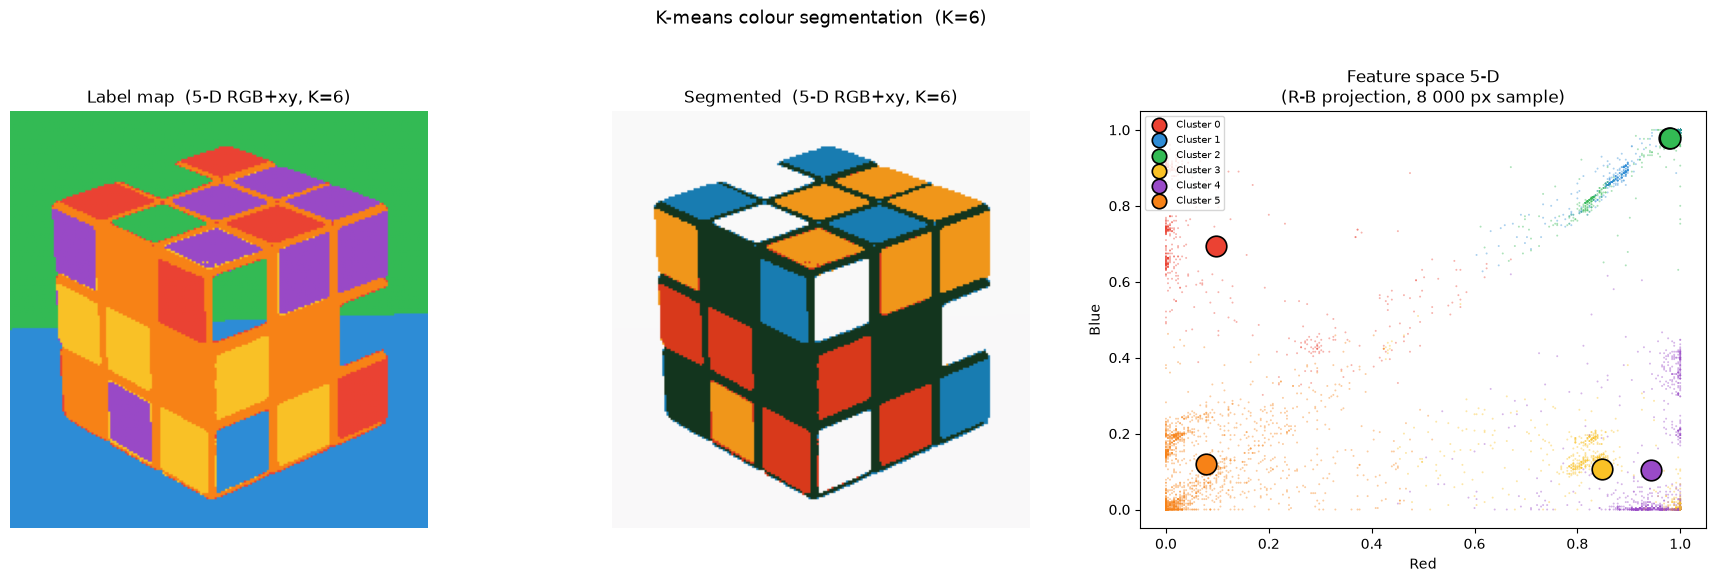

In [ ]:
order_5d = sort_labels_by_hue(centres_5d[:, :3])
centres_5d = centres_5d[order_5d]
labels_5d  = remap_labels(labels_5d, order_5d)
 
fig = plt.figure(figsize=(18, 10))
fig.suptitle("K-means colour segmentation  (K=6)", fontsize=13, y=1.01)
ax4 = fig.add_subplot(2, 3, 1)

# Colour-coded label map
label_img = PALETTE[labels_5d].reshape(H, W, 3)
ax4.imshow(label_img);  ax4.set_title(f"Label map  (5-D RGB+xy, K={K})");  ax4.axis("off")
 
ax5 = fig.add_subplot(2, 3, 2)
ax5.imshow(centres_5d[:, :3][labels_5d].reshape(H, W, C))
ax5.set_title(f"Segmented  (5-D RGB+xy, K={K})");  ax5.axis("off")
 
ax6 = fig.add_subplot(2, 3, 3)
rgb_scatter(ax6, X, labels_5d, centres_5d[:, :3],
            "Feature space 5-D\n(R-B projection, 8 000 px sample)")
 
plt.tight_layout()
plt.show()


### B) Watershed Segmentation

#### a) Load the provided image inputEx5_2.jpg, convert it to grayscale image and compute its gradient magnitude.

#### b) The starting flooding points, also known as seeds or markers, can be determined automatically or manually (ginput). For noisy images, the automatic approach can lead to oversegmentation. Therefore, you should implement a robust version of the algorithm working with manually chosen markers. You can implement an interactive user selection for the seed points or use the following pre-selected seed points:
| X | 40  | 140 | 5  | 130 | 70 | 100 |
|---|-----|-----|----|-----|----|-----|
| Y | 110 | 90  | 20 | 30  | 30 | 130 |

#### c) Implement the watershed segmentation method by yourself. Use the seeds selected in step b. as the starting points for region growing. It is recommended to apply a 4-neighbor topology (introduced in lecture number 3).

#### d) Visualize the final segmentation result, as well as at least two intermediate steps during the region growing procedure. Apply an appropriate colormap to the segmented regions.

#### e) Shortly describe the benefits and drawbacks of the watershed method for the given example image.